In [1]:
from sklearn.datasets import load_iris
dataset = load_iris()
print('Dataset keys:\n', dataset.keys())

Dataset keys:
 dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])


In [2]:
print(dataset['DESCR'][:200] + '\n...')

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attribu
...


In [3]:
# The classification targets
print('Targets:', dataset['target_names'])

Targets: ['setosa' 'versicolor' 'virginica']


In [4]:
# The features that describe each entry
print('Features:', dataset['feature_names'])

Features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


In [5]:
# The date shape: a super important information in the format (samples, features)
print('Data shape:', dataset['data'].shape)

Data shape: (150, 4)


In [6]:
# What is inside the first n values?
print('First n rows:\n', dataset['data'][:3])

First n rows:
 [[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]]


In [16]:
# Now, it will be brutal: The core ML drill in a few lines. SciKit-Learn will split data, shuffle, train... 
# ... separate a small, unseen portion for testing. It's brillant. With using it one spares a huge amount 
# ... of effort and can get to very good results.
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, Y_test = train_test_split(dataset['data'], dataset['target'], random_state=0)


array([[<Axes: xlabel='sepal length (cm)', ylabel='sepal length (cm)'>,
        <Axes: xlabel='sepal width (cm)', ylabel='sepal length (cm)'>,
        <Axes: xlabel='petal length (cm)', ylabel='sepal length (cm)'>,
        <Axes: xlabel='petal width (cm)', ylabel='sepal length (cm)'>],
       [<Axes: xlabel='sepal length (cm)', ylabel='sepal width (cm)'>,
        <Axes: xlabel='sepal width (cm)', ylabel='sepal width (cm)'>,
        <Axes: xlabel='petal length (cm)', ylabel='sepal width (cm)'>,
        <Axes: xlabel='petal width (cm)', ylabel='sepal width (cm)'>],
       [<Axes: xlabel='sepal length (cm)', ylabel='petal length (cm)'>,
        <Axes: xlabel='sepal width (cm)', ylabel='petal length (cm)'>,
        <Axes: xlabel='petal length (cm)', ylabel='petal length (cm)'>,
        <Axes: xlabel='petal width (cm)', ylabel='petal length (cm)'>],
       [<Axes: xlabel='sepal length (cm)', ylabel='petal width (cm)'>,
        <Axes: xlabel='sepal width (cm)', ylabel='petal width (cm)'>,
  

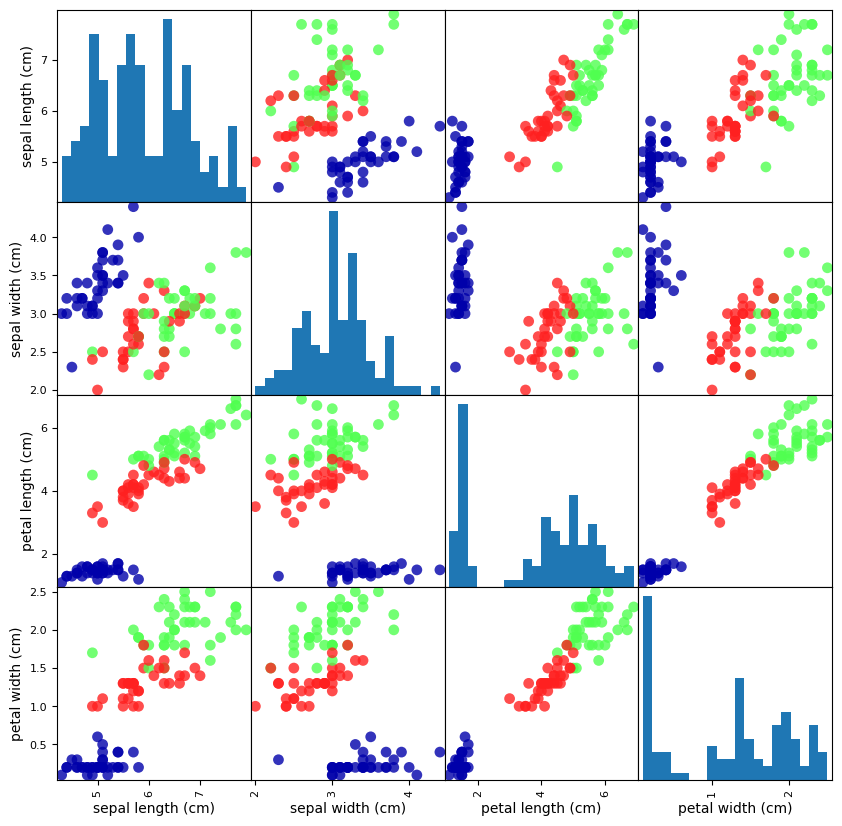

In [17]:
# Let's look into the data. First things first: A dataframe.
import pandas as pd
import mglearn
dataframe = pd.DataFrame(x_train, columns=dataset.feature_names)

# This command generates a grid (matrix) of plots to visualize relationships between all features in the dataset.
# 
# OUTCOME & PARAMETERS:
# 1. THE GRID: It creates an N x N grid where N is the number of features.
#    - Diagonals: Show histograms of each individual feature (distribution of data).
#    - Off-diagonals: Show scatter plots comparing two different features to see if they correlate.
#
# 2. THE DATA (dataframe): Uses the columns as the X and Y axes for the comparison.
#
# 3. COLORING (c=y_train, cmap=mglearn.cm3): 
#    - Points are colored based on their class labels (e.g., the 3 species in the Iris dataset).
#    - 'mglearn.cm3' applies a specific high-contrast color map (usually Blue, Red, Green) 
#      to make the different clusters easy to distinguish visually.
#
# 4. AESTHETICS:
#    - figsize=(10, 10): Sets a large enough canvas to see all subplots clearly.
#    - marker='o': Uses solid circles for the data points.
#    - s=60: Sets the size of the points to 60 (large enough to see, small enough to avoid total overlap).
#    - alpha=.8: Adds 80% opacity so you can see where points are "stacking" or overlapping.
#
# 5. HISTOGRAMS (hist_kwds={'bins':20}): 
#    - Divides the diagonal distribution plots into 20 bars for a detailed look at data density.
pd.plotting.scatter_matrix(dataframe, c=y_train, figsize=(10, 10), marker='o', 
                           hist_kwds={'bins':20}, s=60, alpha=.8, cmap=mglearn.cm3)

In [18]:
# Trying the K-Nearest neighbor - Literaly: The nearest neighbor of a given new data point in the original training set.
from sklearn.neighbors import KNeighborsClassifier
# 'n_neighbors' is the "K" in KNN. It defines how many labeled neighbors 
# the model 'votes' with to classify a new, unknown point.
#
# n_neighbors=1:
# - The model looks ONLY at the single closest point. 
# - It is very precise with the training data but "brittle."
# - High risk of 'Overfitting': It might follow noise or outliers too closely,
#   leading to jagged, complex decision boundaries.
#
# n_neighbors=4:
# - The model looks at the 4 closest points and takes a majority vote.
# - If 3 neighbors are 'Red' and 1 is 'Blue', the new point is classified as 'Red'.
# - Higher K-values lead to 'Smoothing': The decision boundaries become less 
#   wiggly and more stable, but if K is too high, the model misses small patterns.
knn = KNeighborsClassifier(n_neighbors=1)
# The training itself
knn.fit(x_train, y_train)


,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",1
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [19]:
# Now, the model trained. Let's see how it performs with classifying an Iris we found in the wild:
import numpy as np 
# an array holding the values of the features: sepal length, sepal width, petal lgth, petal width
# IMPORTANT: double sq brackets? Yes: to get to a two dimensions array 1 (line) x 4 (columns)
x_just_found_iris = np.array([[5, 2.9, 1, 0.2]])
# The prediction is a number, an index of a class
prediction = knn.predict(x_just_found_iris)
# To find the class name one gotta index if in dataset dictionary-like:
print('Predicted class: ',dataset['target_names'][prediction])

Predicted class:  ['setosa']


In [20]:
# As I don't know anything about flowers, I will just test the model against the unseen, test data:

In [25]:
y_pred = knn.predict(x_test)
# An array of results out of an array of inputs. How good did it perform?
# score numpy way and model way: 
print('Score: {:.2f}'.format(np.mean(y_pred == Y_test)))
print('Score: {:.2f}'.format(knn.score(x_test, Y_test)))

Score: 0.97
Score: 0.97
